# 波士顿房价预测 - 线性回归实践

### 什么是线性回归？
线性回归（Linear Regression）是机器学习中最基础且应用最广的回归算法之一。它通过建立自变量（特征）与因变量（目标值）之间的线性函数关系来进行预测。其核心思想是寻找一条“最佳拟合线”，使得所有预测值与实际值之间的总误差（通常使用均方误差 MSE 衡量）达到最小。

### 房价预测的意义
1. **决策支持**：通过分析影响房价的关键因素（如房间数、犯罪率、交通便利性等），为购房者、投资者和城市规划者提供客观的数据参考。
2. **市场分析**：房价及其波动是城市经济状况、人口结构和政策导向的重要风向标。
3. **经典建模入门**：房价预测是回归分析最经典的教学案例之一，通过它可以掌握从数据预处理到模型评估的完整机器学习工作流。

本项目将使用波士顿房价数据集，展示如何构建并优化一个线性回归预测模型。

In [16]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split #注释：内置的拆分数据函数
from sklearn.linear_model import LinearRegression #注释：线性回归模型
from sklearn.metrics import mean_squared_error , r2_score #注释：回归预测评估函数，MSE，R2
import seaborn as sns

# 1. 设置中文字体与负号显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'sans-serif'] 
plt.rcParams['axes.unicode_minus'] = False 

# 2. 使图表直接在 notebook cell 中展示
%matplotlib inline

## 1. 数据准备

首先，我们导入必要的库，并从指定的数据源加载原始数据。由于波士顿房价数据集的原始格式较为特殊（记录跨行），我们需要进行手动拼接和清洗，并将其转换为标准的 Pandas DataFrame 格式。

In [17]:
# 通过数据集的源地址读取Boston房价数据
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

print(raw_df.head())
# 数据分为多行显示，每一行包含不完整的记录, 需要合并两行才能形成完整的记录。如下图。
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
#注释：raw_df.values,即将DataFrame转变为numpy
#注释：raw_df.values[::2,:]指选取raw_df数组中所有偶数行的所有列
#注释：raw_df.values[::2,:2]指选取raw_df数组中所有奇数行，前两行
#注释：np.hstack(),为numpy中水平堆叠函数，将上述两个数组进行拼接，列方向
target = raw_df.values[1::2, 2]
#注释：选取raw_df数组中奇数行的第三列，索引为2，将目标值存储在target中
#拼接特征data和预测目标target
complete_data = np.column_stack([data, target])
#注释：numpy中用于拼接的函数，拼接后，data在前面，target在最后
columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD','TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
 
# 创建DataFrame，方便数据分析和特征处理
boston = pd.DataFrame(complete_data, columns=columns)
#注释：将numpy类型的complete_data转变为DataFrame类型，并添加列名
# print(boston.head())

          0      1      2    3      4      5     6       7    8      9     10
0    0.00632  18.00   2.31  0.0  0.538  6.575  65.2  4.0900  1.0  296.0  15.3
1  396.90000   4.98  24.00  NaN    NaN    NaN   NaN     NaN  NaN    NaN   NaN
2    0.02731   0.00   7.07  0.0  0.469  6.421  78.9  4.9671  2.0  242.0  17.8
3  396.90000   9.14  21.60  NaN    NaN    NaN   NaN     NaN  NaN    NaN   NaN
4    0.02729   0.00   7.07  0.0  0.469  7.185  61.1  4.9671  2.0  242.0  17.8


## 2. 探索性数据分析 (EDA)

在进行建模之前，我们首先查看数据的基本结构、统计特征以及分布情况，以便识别数据中的模式、异常值或缺失值。

In [18]:
#查看数据字段，数据类型等
print(boston.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB
None


In [19]:
#描述性统计：得到每个字段的计数，均值，标准差，最大最小值，分位数等统计特征，可初步识别异常数据
#直方图：可以直观的看到数据的分布特征（正态分布，偏态分布等）
print(boston.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

### 2.1 变量相关性分析

我们利用相关矩阵和热力图来分析特征变量与目标变量（房价 MEDV）之间的线性关系。相关性较高的变量往往是模型预测的关键。

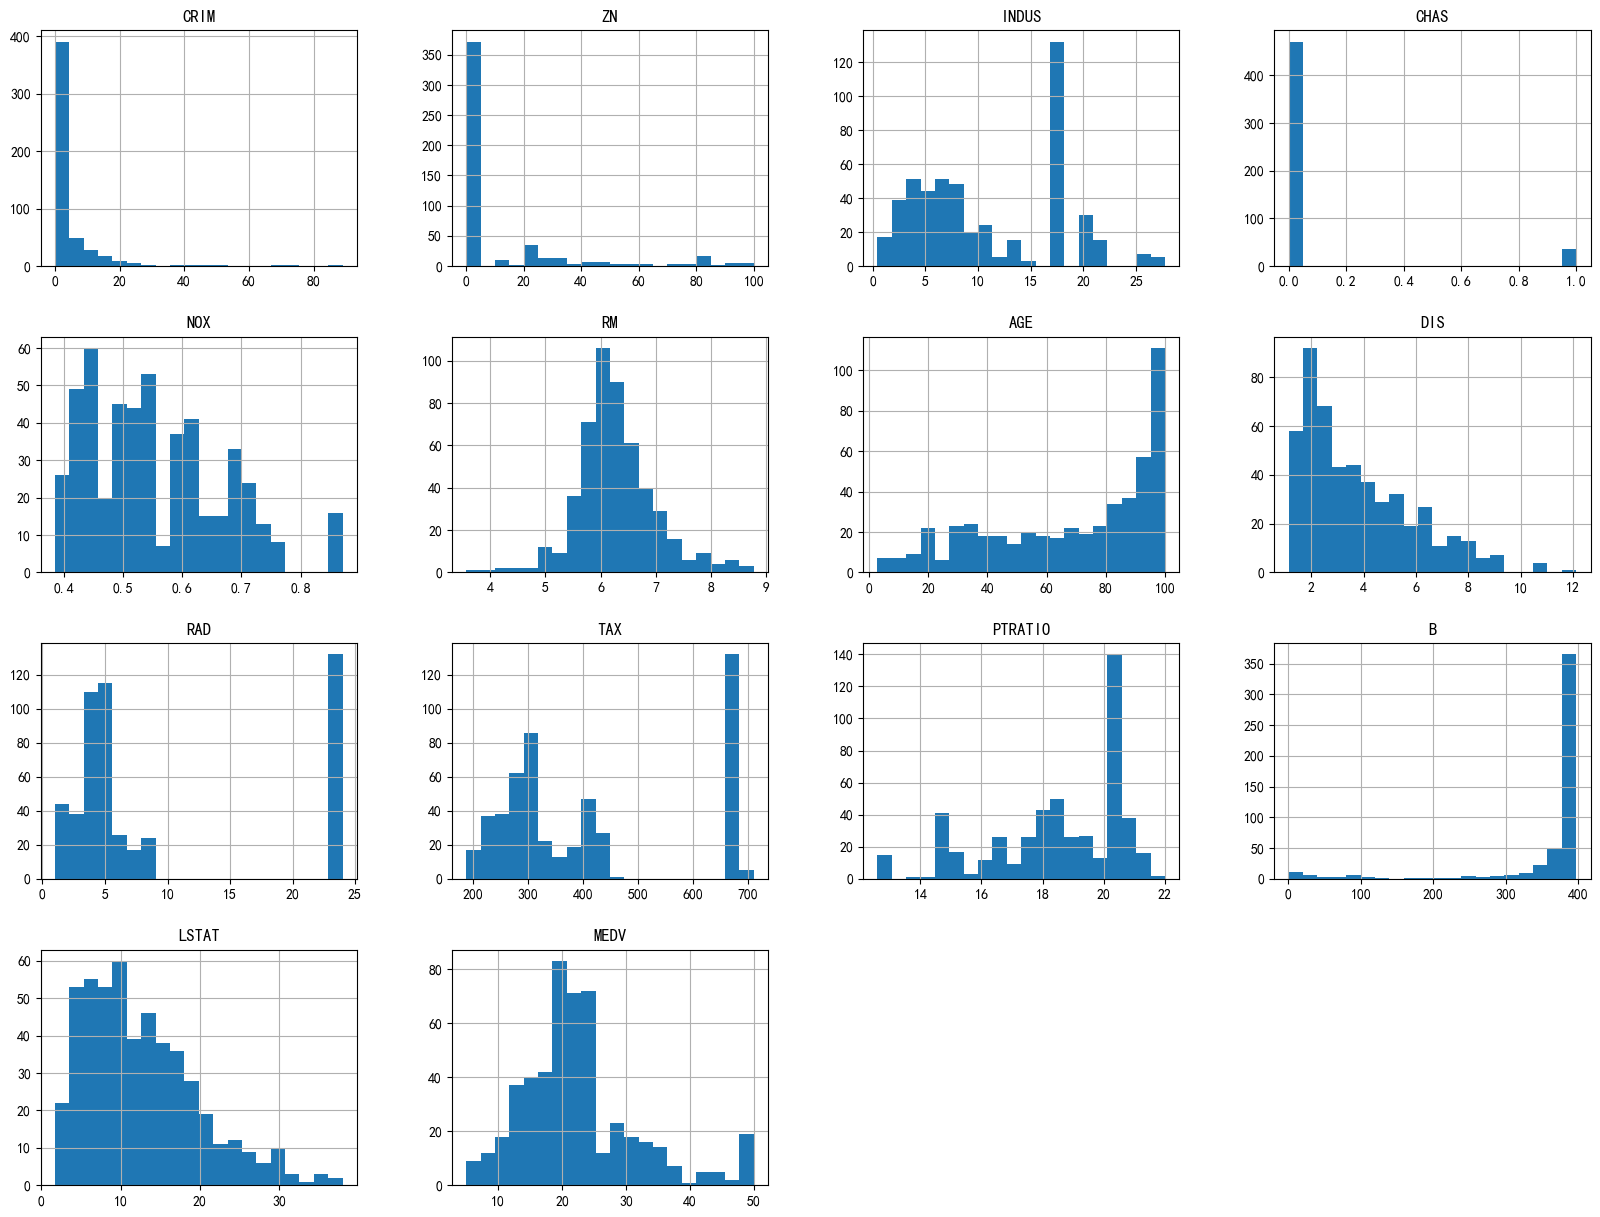

In [20]:
#对每个字段画直方图
boston.hist(bins=20, figsize=(20,15))
#注释：bins 参数指定了直方图的区间数量即20，bins 值越大，区间越窄，直方图越能反映数据的细节
plt.show()

In [21]:
#结论：上图是表示目标变量MEDV与各个特征变量之间的相关性，由图可知，MEDV与RM相关系数为0.70，
# 即为中度正相关性，MEDV与LSTAT相关系数为-0.74，称中度负相关

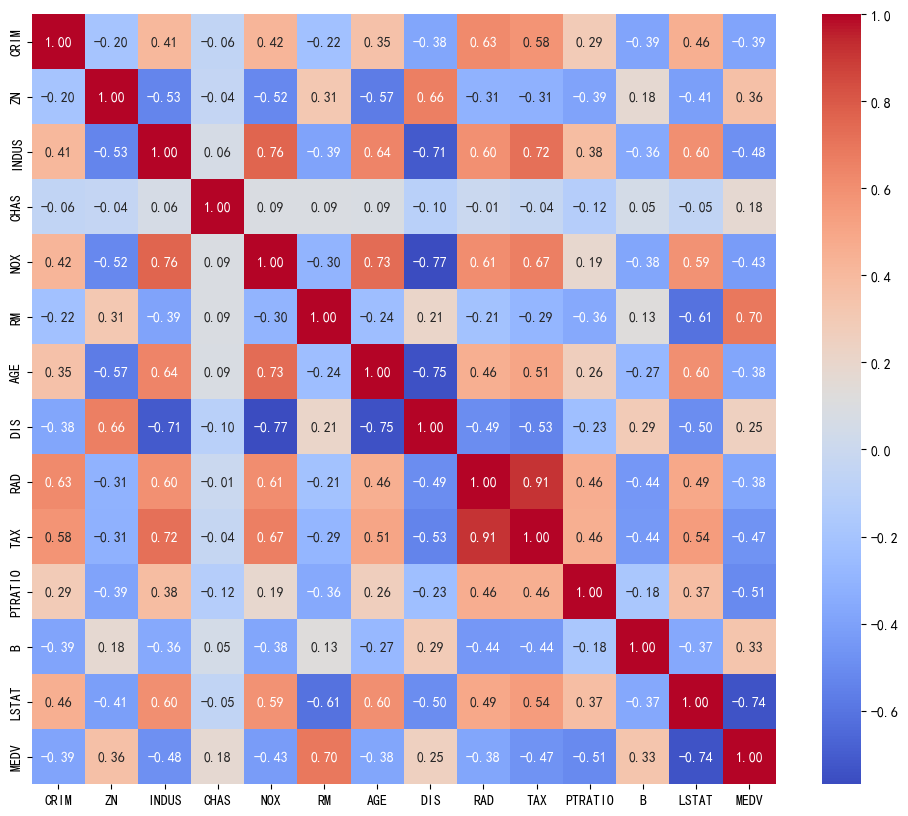

In [22]:
# 计算相关矩阵
# corr()是 Pandas 库中的一个方法，用于计算数据框（DataFrame）中各列之间的相关系数矩阵。
# 相关系数用于衡量两个变量之间的线性关系，其值介于 -1 和 1 之间
correlation_matrix = boston.corr()
# 可视化相关矩阵
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
#注释：heatmap是绘制热力图，annot=True指会在热力图的方格子上显示数值
# fmt=".2f"指的是小数点位数，cmap指颜色映射，coolwarm指红蓝表示数值，蓝表示负，红表示正
plt.show()

In [23]:
#查看与目标变量相关性最高的特征变量
correlation_with_target=correlation_matrix['MEDV'].sort_values(ascending=False)
#注释：对MEDV列进行降序排列
print(correlation_with_target)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


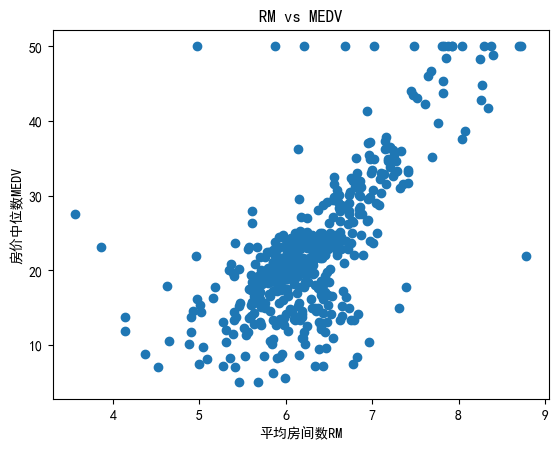

In [24]:
#分析房间数RM与房价的关系
x1=boston['RM']
y1=boston['MEDV']
plt.scatter(x1,y1)
plt.xlabel('平均房间数RM')
plt.ylabel('房价中位数MEDV')
plt.title('RM vs MEDV')
plt.show()
#绘制RM与房价的散点图
#结论：由散点图可知，RM与MEDV呈现正相关

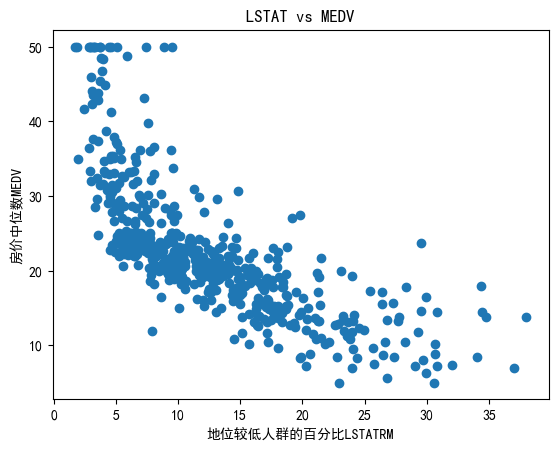

In [25]:
#分析人口中地位较低人群的百分比LSTATRM与房价的关系
x2=boston['LSTAT']
y2=boston['MEDV']
plt.scatter(x2,y2)
plt.xlabel('地位较低人群的百分比LSTATRM')
plt.ylabel('房价中位数MEDV')
plt.title('LSTAT vs MEDV')
plt.show()
#结论：由散点图可知，LSTAT与MEDV呈现负相关

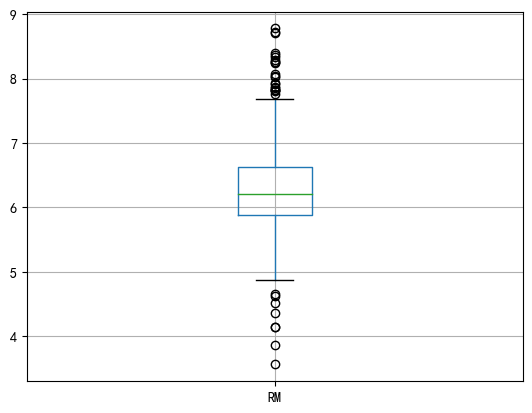

In [26]:
# 特征变量的处理
# 特征选择
# 选择与目标变量高度相关的特征变量，同时去除共线性特征，
# 从相关性图可以看出['RM','LSTAT','TAX','INDUS','AGE']这几个特征变量与目标变量的相关性绝对值都超过了0.5，
# 正常情况下可以删除其他相关性不强的特征，但Boston数据量较小，这里就不做特征选择

# 异常值处理（箱线图）
boston.boxplot(column=['RM'])
plt.show()

## 3. 特征处理与工程

在这一步中，我们处理数据中的潜在异常。通过箱线图定位“异常”样本，并采取合理的业务逻辑（如盖帽法/截断处理）来减少异常值对线性回归模型的影响。

In [27]:
#删除异常值，超过上界的正常业务情况可以认为是异常值，异常值可以替换，可以删除
boston.loc[boston['RM']>8,'RM']=8
#注释：将RM列数值超过8的替换为8

## 4. 模型训练

我们将数据集划分为**训练集**和**测试集**。使用训练集构建多元线性回归模型，并使用训练好的参数在测试集上进行预测，计算均方误差 (MSE) 和决定系数 ($R^2$) 来衡量性能。

In [28]:
#线性回归模型假设多个影响房价的因素和房价之间是线性关系，属于多元线性回归
#线性回归模型训练的目的是找到一组参数使得模型预测的误差最小，这里面用到了损失函数，最小二乘法，正则化等理论

##线性模型
#拆分特征和目标变量
x= boston.drop(columns='MEDV',axis=1)
y= boston['MEDV']
#数据分割，拆分出模型训练集和测试数据集
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=42)
#注释：将数据集分为训练集和测试集，
#注释：test_size=0.1即测试集数据占比为10%，训练集为90%，random_state=42即用于控制数据分割的随机性
#创建模型
model=LinearRegression()
#调用训练模型参数，传入训练数据集
model.fit(x_train,y_train)
#模型预测，传入测试数据集，输出预测值
y_pred=model.predict(x_test)
# 通过预测值和测试值来计算均方误差
mse = mean_squared_error(y_test,y_pred)
# 通过预测值和测试值来计算决定系数
r2=r2_score(y_test,y_pred)
print(f"均方误差 (MSE): {np.sqrt(mse)}")
print(f"决定系数 (R^2): {r2}")

均方误差 (MSE): 3.9050820485113213
决定系数 (R^2): 0.7557482677014942


## 5. 结果可视化与评估

最后，我们通过绘制“实际价格 vs 预测价格”的散点图，直观地观察模型的预测偏差。预测点离红色对角线越近，表示模型的拟合效果越好。

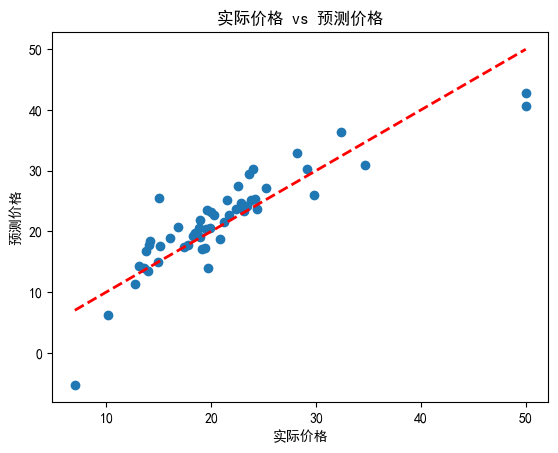

In [29]:
# 结果可视化
# 判断实际价格与预测价格的偏差
# 画散点图判断预测值与测试值偏差
plt.scatter(y_test,y_pred)
plt.xlabel('实际价格')
plt.ylabel('预测价格')
plt.title('实际价格 vs 预测价格')
#辅助线
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.show()
#结论：预测点越接近对角线，说明预测值和实际值，越接近

## 6. 教学案例拓展与思考

本项目完成了一个基础的房价预测模型。为了进一步提升建模能力，请同学们思考并尝试以下问题：

### 思考题 1：特征缩放（Feature Scaling）对线性回归的影响大吗？
- **解答思路**：
  - **理论**：对于普通的最小二乘线性回归（OLS），特征缩放不会改变预测结果，但它会改变回归系数（$\beta$）的量纲。
  - **重要性**：当引入**正则化**（如 Lasso 或 Ridge）或使用**梯度下降法**求解模型时，特征缩放（标准化或归一化）至关重要。不同量纲（如房间数 RM 为 1-9，土地面积 ZN 为 0-100）会导致模型对大数值特征过于敏感。

### 思考题 2：数据集中的 CHAS 变量（是否临河）是 0/1 离散值，它与其他连续变量在处理上有什么区别？
- **解答思路**：
  - **分析**：CHAS 属于分类特征（Categorical Feature）。在线性回归中，我们通常将其处理为**哑变量（Dummy Variable）**。
  - **物理意义**：在线性方程中，CHAS 的系数代表了“在其他条件相同的情况下，房子临河比不临河带来的溢价潜力”。

### 思考题 3：如果某些特征与房价之间不是线性关系（例如呈现抛物线形状），该如何处理？
- **解答思路**：
  - **方法**：可以引入**多项式特征（Polynomial Features）**。例如，如果发现 LSTAT（地位较低人群占比）与房价呈现非线性趋势，可以尝试加入 $LSTAT^2$ 项。
  - **转化**：这样即便算法本身是线性回归，也能捕捉到变量间的非线性关系。

### 思考题 4：平均绝对误差（MAE）和均方误差（MSE）在模型评估时有什么侧重点？
- **解答思路**：
  - **MSE**：由于计算了误差的平方，MSE 对**离群点（Outliers）**非常敏感。巨大的预测偏差会被平方放大，促使模型尽量减少较大的错误。
  - **MAE**：对离群点更具有鲁棒性，它反映的是平均预测误差的绝对水平。

### 思考题 5：如何判断模型是否存在过拟合（Overfitting）？
- **解答思路**：
  - **判断**：对比**训练集得分**和**测试集得分**。如果训练集上的 $R^2$ 远高于测试集，说明模型学习到了训练集中的噪声，泛化能力较差。
  - **对策**：可以考虑精简特征（特征选择）或引入正则化技术。

---
希望同学们通过以上思考，能够从“跑通代码”进阶到“理解模型背后逻辑”的层面。尝试在代码中实验这些想法吧！